In [1]:
library(randomForest)
set.seed(2) 

ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.



In [2]:
data<-read.csv("train_values.csv",stringsAsFactors = T)
data_labels<-read.csv("train_labels.csv",stringsAsFactors = T)
datam<-merge(data,data_labels,by=c('building_id','building_id'))

We use the rfcv function to see how the CV score evolves when removing least important features, with the optimal parameters obtained from randomForestTune.ipynb.

NOTE TO SELF: ADD PROGRESSBAR

Warning message in randomForest.default(trainx[idx != i, imp.idx, drop = FALSE], :
"invalid mtry: reset to within valid range"
Warning message in randomForest.default(trainx[idx != i, imp.idx, drop = FALSE], :
"invalid mtry: reset to within valid range"
Warning message in randomForest.default(trainx[idx != i, imp.idx, drop = FALSE], :
"invalid mtry: reset to within valid range"
Warning message in randomForest.default(trainx[idx != i, imp.idx, drop = FALSE], :
"invalid mtry: reset to within valid range"
Warning message in randomForest.default(trainx[idx != i, imp.idx, drop = FALSE], :
"invalid mtry: reset to within valid range"
Warning message in randomForest.default(trainx[idx != i, imp.idx, drop = FALSE], :
"invalid mtry: reset to within valid range"
Warning message in randomForest.default(trainx[idx != i, imp.idx, drop = FALSE], :
"invalid mtry: reset to within valid range"
Warning message in randomForest.default(trainx[idx != i, imp.idx, drop = FALSE], :
"invalid mtry: reset to with

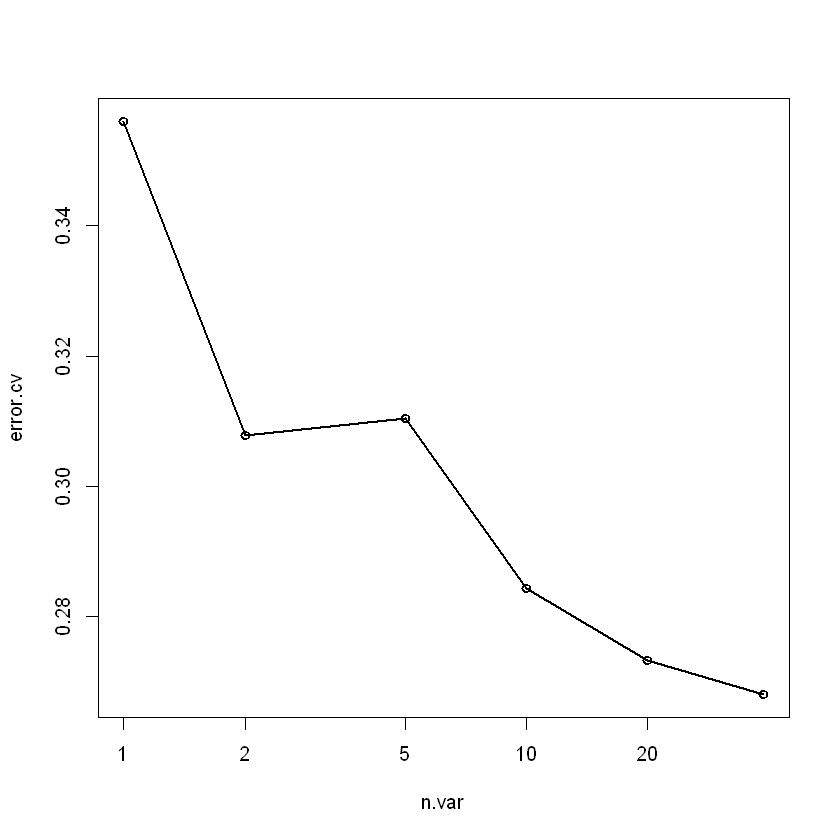

In [4]:
n_trees <- 250
features_per_split <- 12
datam_idx <- sample(1:nrow(datam))
split <- floor(nrow(datam)*0.8)
target_variable <- ncol(datam)
train_data <- datam[datam_idx[1:split],]
test_data <- datam[datam_idx[(split+1):nrow(datam)],]   

cv_RF<-rfcv(train_data[,-c(target_variable)],as.factor(train_data[,c(target_variable)]),cv.fold=10,ntree=n_trees,mtry=function(p) max(1,floor(2*sqrt(p))))

with(cv_RF, plot(n.var, error.cv, log="x", type="o", lwd=2))

Let us compare the score for normal variables and geoprocessed variables.

In [ ]:
n_trees <- 1000
nfeat <- ncol(datam)-2 #I remove 2 to remove building_id and damage_grade
m_tries <- 12
accuracy_vec <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec)<-c('n_trees','mtry','F1')
nrows<-nrow(datam)
datam_idx <- sample(1:nrows)
split <- floor(nrows*0.8)
target_variable <- ncol(datam)-1 #I will remove id_variable too so I need to remove 1 col
id_variable <- match('building_id', colnames(datam))

#3.1 Take the first half of the dataset as a training data set
train_data <- datam[datam_idx[1:split],-c(id_variable)]

#3.2 Take the second half of the dataset as a hold out or test data set
test_data <- datam[datam_idx[(split+1):nrows],-c(id_variable)]

model <- randomForest(x=train_data[,-c(target_variable)],
                        y=as.factor(train_data[,c(target_variable)]),
                        ntree=n_trees,mtry=m_tries,doBest=TRUE,keep.forest=TRUE,importance=TRUE,do.trace=TRUE)
#model<-tuneRF(x=train_data[,-c(target_variable),drop=F],
#    y=as.factor(train_data[,c(target_variable)]),ntreeTry=i,mtryStart=12,plot=TRUE,trace=TRUE,doBest=TRUE,importance=TRUE,do.trace=TRUE)
#model
yhat<-predict(model,test_data[,-c(target_variable),drop=F])                      
accuracy_vec[nrow(accuracy_vec)+1,]<-c(n_trees,m_tries,F1_Score_micro(as.factor(test_data[,c(target_variable)]),yhat))
print(paste("Best F1 Score - ",n_trees, 'trees','- mtry',m_tries,':',accuracy_vec[nrow(accuracy_vec),3],n=1))
rm('model')
rm('datam')

: 

: 

In [ ]:
datam<-read.csv("data_geoprocessed.csv",stringsAsFactors = T)
id_variable <- match('building_id', colnames(datam))
target_variables<-match('damage_grade', colnames(datam))

nfeat <- ncol(datam)-2 #I remove 2 to remove building_id and damage_grade
nrows<-nrow(datam)
datam_idx <- sample(1:nrows)
split <- floor(nrows*0.8)
target_variable <- ncol(datam)-1 #I will remove id_variable too so I need to remove 1 col
id_variable <- match('building_id', colnames(datam))

#3.1 Take the first half of the dataset as a training data set
train_data <- datam[datam_idx[1:split],-c(id_variable)]

#3.2 Take the second half of the dataset as a hold out or test data set
test_data <- datam[datam_idx[(split+1):nrows],-c(id_variable)]

model <- randomForest(x=train_data[,-c(target_variable)],
                        y=as.factor(train_data[,c(target_variable)]),
                        ntree=n_trees,mtry=m_tries,doBest=TRUE,keep.forest=TRUE,importance=TRUE,do.trace=TRUE)
#model<-tuneRF(x=train_data[,-c(target_variable),drop=F],
#    y=as.factor(train_data[,c(target_variable)]),ntreeTry=i,mtryStart=12,plot=TRUE,trace=TRUE,doBest=TRUE,importance=TRUE,do.trace=TRUE)
#model
yhat<-predict(model,test_data[,-c(target_variable),drop=F])                      
accuracy_vec[nrow(accuracy_vec)+1,]<-c(n_trees,m_tries,F1_Score_micro(as.factor(test_data[,c(target_variable)]),yhat))
print(paste("Best F1 Score geoprocessed - ",n_trees, 'trees','- mtry',m_tries,':',accuracy_vec[nrow(accuracy_vec),3],n=1))
        